## 📊 Data Loading and Exploration

In this section, we import the required libraries, load the **Customer Churn dataset**, and display a random sample of the data.

### 📦 Import Libraries

In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import tensorflow as tf 
from tensorflow import keras
import warnings


warnings.filterwarnings('ignore')
df = pd.read_csv(r"C:\Users\Dell\Downloads\archive (28)\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.sample(7)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1496,3195-TQDZX,Male,0,No,No,3,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,20.25,61.45,No
1581,2782-JEEBU,Male,0,No,No,21,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,Yes,Mailed check,36.00,780.15,No
4131,2876-VBBBL,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.25,20.25,Yes
2745,4826-XTSOH,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,86.05,86.05,Yes
188,0956-SYCWG,Female,0,No,No,13,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Electronic check,19.65,244.8,No
3906,6372-RFVNS,Female,0,Yes,No,1,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,No,Electronic check,78.80,78.8,Yes
2116,4349-GFQHK,Male,0,No,No,1,Yes,Yes,DSL,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,54.35,54.35,Yes


## 🧹 Data Cleaning – Explanation

In this step, several preprocessing and cleaning operations were applied to prepare the dataset for analysis and modeling.

---

### 🔍 Missing Values and Duplicates

The dataset was first checked for missing values and duplicated rows:
- Missing values were mainly found in the `TotalCharges` column.
- Duplicate rows were also inspected to ensure data quality.

---

### 🔢 Converting `TotalCharges`

The `TotalCharges` column originally contained non-numeric values (stored as strings).  
It was converted into a numeric format:
- Invalid values were coerced into `NaN`
- This step is important to allow numerical analysis and modeling

---

### 🗑️ Handling Missing Values

After conversion, missing values appeared in `TotalCharges`.  
These rows were removed using `dropna()`.

✔ This approach is acceptable because:
- The number of missing values is relatively small  
- It simplifies preprocessing  

⚠ However:
- If the missing data were large, imputation would be a better choice

---

### 🔄 Converting `SeniorCitizen`

The `SeniorCitizen` column was transformed from numeric values:
- `0 → No`
- `1 → Yes`

✔ This improves readability and makes the feature categorical

---

### 🧾 Categorical Features

All categorical columns were selected for inspection:
- This helps understand feature distributions  
- Useful before encoding (e.g., One-Hot Encoding)

---

### 📊 Exploring Value Distributions

Value counts were displayed for each categorical feature:
- Helps identify imbalanced categories  
- Helps detect unusual or inconsistent values  

---

### ❌ Removing Irrelevant Columns

Some columns were excluded from the feature set:
- `customerID` → just an identifier, no predictive value  
- `Churn` → target variable, should not be part of features  

✔ This is an important step to avoid data leakage

---

### ⚠️ Important Observations

- Keeping original categories (e.g., *No internet service*, *No phone service*) preserves important information  
- Avoiding unnecessary category merging improves model quality  
- Dropping missing values is acceptable here, but not always ideal in larger datasets  

---

### ✅ Final Result

After these steps:
- Data types are consistent  
- Missing values are handled  
- Categorical variables are clean and interpretable  
- Irrelevant columns are removed  

➡️ The dataset is now ready for:
- Encoding  
- Feature engineering  
- Model training  

In [18]:
print("The missing data is : ")
print(df.isna().sum())
print("*"*150)
print("the duplicated data is : ",df.duplicated().sum())
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("The number of NaN after conver ",df['TotalCharges'].isna().sum())
print("drop of numer of NaN" )
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
df['SeniorCitizen'] = df['SeniorCitizen'].replace({ 1 : 'Yes' ,0 : 'No'},inplace = True)
df_object = df.select_dtypes(['object'])
df_object = df_object.drop(['Churn'],axis = 1 )
df_object.drop(['customerID'],axis = 1 ,inplace = True)
for i in df_object :
    print(df[i].value_counts())
    print("===================")

The missing data is : 
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
******************************************************************************************************************************************************
the duplicated data is :  0
The number of NaN after conver  11
drop of numer of NaN
gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6

# 🚀 Model Training & Evaluation Pipeline

In this stage, we transition from data preparation to building and assessing machine learning models. The goal is to identify the best algorithm for predicting customer churn while balancing precision and recall.

### 🛠 1. Feature Engineering & Preprocessing
* **Target Transformation:** Converted the `Churn` target variable from categorical (Yes/No) to binary (1/0).
* **Categorical Encoding:**
    * **OneHotEncoder:** Applied to nominal variables (e.g., `PaymentMethod`, `InternetService`) to prevent the model from assuming an unintended mathematical order.
    * **LabelEncoder:** Applied to the `Contract` column to preserve its ordinal nature (Month-to-month < One year < Two year).
* **Data Splitting:** Divided the dataset into **80% training** and **20% testing** sets. We used `stratify=y` to ensure the churn distribution remains consistent across both sets.
* **Feature Scaling:** Implemented **StandardScaler** on numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) to ensure all features contribute equally to the model's decision-making process.



### 🤖 2. Model Selection & Benchmarking
To find the most robust solution, we benchmarked six different algorithms:
1. **Logistic Regression:** Our baseline linear model.
2. **Random Forest:** An ensemble method handling non-linear relationships with `class_weight='balanced'`.
3. **Decision Tree, SVM, & KNN:** Diverse classifiers to explore different decision boundaries.
4. **XGBoost:** A powerful Gradient Boosting framework optimized for performance and speed.

### 📈 3. Performance Optimization (Threshold Tuning)
Since detecting churners (Class 1) is more critical than identifying non-churners, we performed:
* **Threshold Adjustment:** Shifted the classification threshold to **0.6** to optimize the balance between False Positives and False Negatives.
* **Comprehensive Evaluation:** Used Confusion Matrices and ROC-AUC curves to validate the model's discriminative power.



### 🔍 4. Interpretability: Feature Importance
We utilized the **Random Forest** and **Logistic Regression** coefficients to extract "Business Insights," identifying exactly which factors (like Contract type or Tenure) drive customers to stay or leave.

In [21]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
import pandas as pd

# تحديد الأعمدة الـ object
object_col = df.select_dtypes(include='object')
object_col.drop(['customerID','gender','Contract'],axis =1 ,inplace = True)
object_cols = object_col.columns
# إنشاء الـ encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# تطبيق التحويل
encoded = encoder.fit_transform(df[object_cols])

# تحويل الناتج إلى DataFrame
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(object_cols),
    index=df.index
)

# حذف الأعمدة الأصلية
df = df.drop(columns=object_cols)

# دمج الأعمدة الجديدة
df = pd.concat([df, encoded_df], axis=1)
df['Contract'] = LabelEncoder().fit_transform(df['Contract'])
X = df.drop(['Churn','customerID','gender'],axis =1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # مهم جدًا 🔥
)
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# افترضنا أن هذه هي الأعمدة الرقمية
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
model=LogisticRegression(class_weight='balanced')



model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409

--- تقرير أداء النموذج ---
Accuracy  (الدقة العامة): 0.7630
Precision (الدقة):       0.7904
Recall    (الاستدعاء):   0.7630
F1-Score  (مقياس F1):    0.7717

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409


--- Confusion Matrix ---


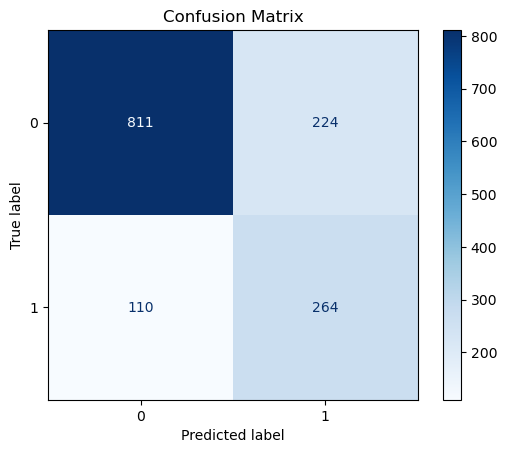

AUC-ROC Score: 0.8418


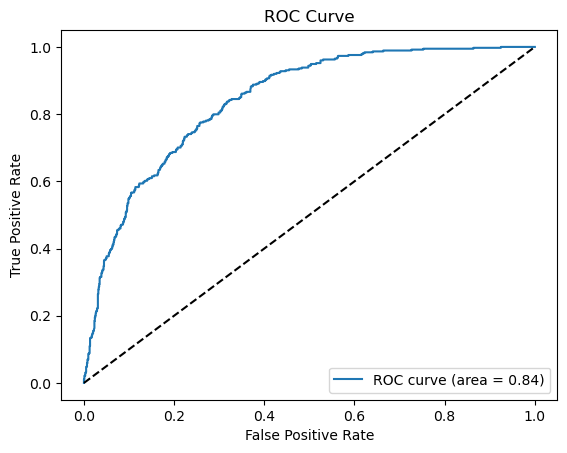

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report, 
    roc_auc_score, 
    roc_curve,
    ConfusionMatrixDisplay
)

def evaluate_classification_model(y_true, y_pred, y_probs=None):
    """
    دالة شاملة لتقييم أداء نموذج التصنيف
    y_true: القيم الحقيقية
    y_pred: القيم التي توقعها النموذج
    y_probs: احتمالات التوقع (مطلوبة لحساب AUC-ROC)
    """
    
    print("--- تقرير أداء النموذج ---")
    

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"Accuracy  (الدقة العامة): {accuracy:.4f}")
    print(f"Precision (الدقة):       {precision:.4f}")
    print(f"Recall    (الاستدعاء):   {recall:.4f}")
    print(f"F1-Score  (مقياس F1):    {f1:.4f}")
    

    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred))
    

    print("\n--- Confusion Matrix ---")
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()


    if y_probs is not None:
        auc = roc_auc_score(y_true, y_probs)
        print(f"AUC-ROC Score: {auc:.4f}")
        
        fpr, tpr, _ = roc_curve(y_true, y_probs)
        plt.figure()
        plt.plot(fpr, tpr, label=f'ROC curve (area = {auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.show()


y_real = y_test

y_probs = model.predict_proba(X_test)[:, 1]


new_threshold = 0.6
y_pred_new = (y_probs >= new_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_new))
evaluate_classification_model(y_real, y_pred_new, y_probs)


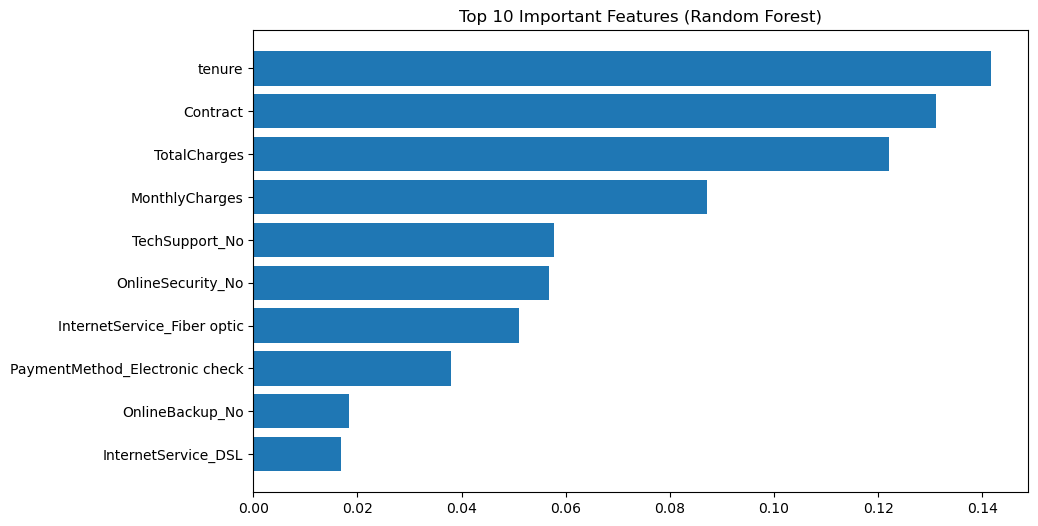

In [27]:
import pandas as pd
import matplotlib.pyplot as plt


importances = models["Random Forest"].feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 Important Features (Random Forest)')
plt.show()

# 🎯 Feature Importance & Actionable Business Insights

In this final step, we transition from predictive modeling to **descriptive analytics**. By extracting the coefficients from our model, we can identify the key drivers behind customer behavior.

### 🔍 Understanding the Impact
The chart below visualizes the **Top 10 Features** that influence the model's decision. This is crucial for stakeholders to understand why customers are leaving.

* **Red Bars (Positive Coefficients):** These features increase the log-odds of churn. A higher value here means the customer is **more likely to leave**.
* **Green Bars (Negative Coefficients):** These features decrease the probability of churn. They represent **retention factors** that keep customers loyal.

### 💡 Business Strategy Recommendations
Based on the results, we can provide data-driven recommendations:
1.  **Contract Migration:** If "Month-to-month contracts" show a high positive impact, marketing should focus on migrating these users to annual plans.
2.  **Loyalty Programs:** For features like "Tenure" that show high negative impact, early-stage retention programs should be prioritized for new customers.
3.  **Service Quality:** If specific services (like Fiber Optic) are driving churn, a technical audit of those services may be required.

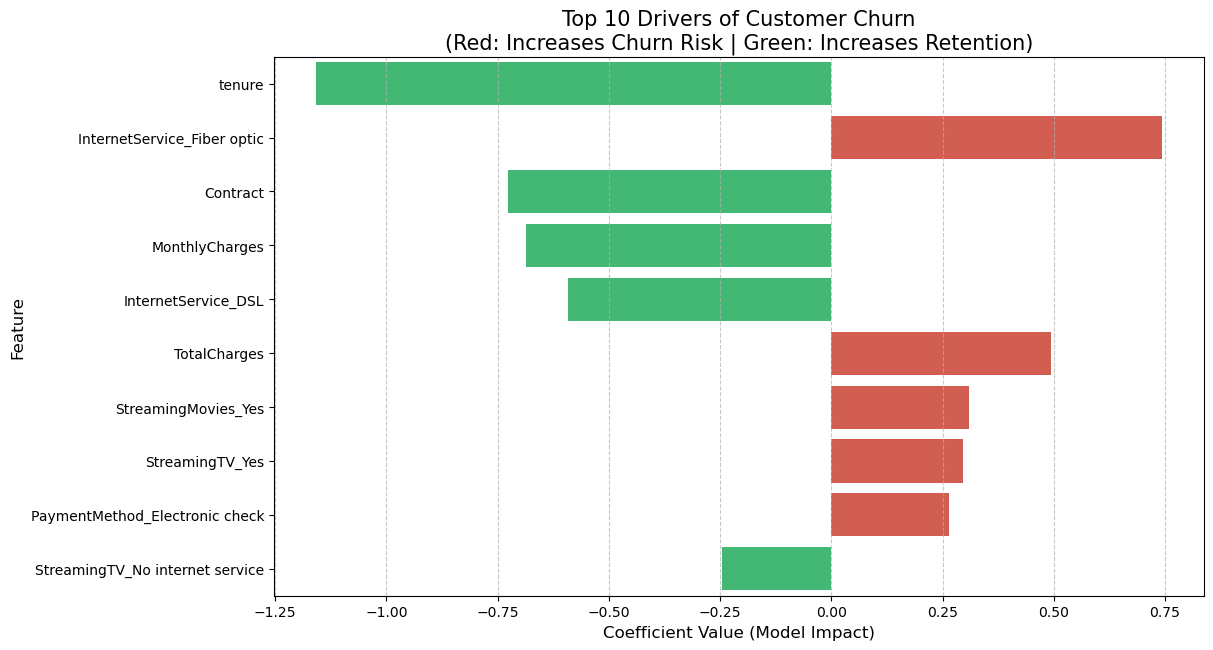

--- Business Insights ---
1. The strongest predictor of churn is: tenure
2. Red bars indicate features that make customers MORE likely to leave.
3. Green bars indicate features that help in KEEPING customers.


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. استخراج أسماء الأعمدة بعد عملية الـ Encoding (تأكد من استخدام أسماء أعمدة X_train)
feature_names = X_train.columns
coefficients = model.coef_[0]

# 2. إنشاء DataFrame لسهولة العرض والترتيب
feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

# ترتيب المتغيرات بناءً على القيمة المطلقة (الأكثر تأثيراً أولاً)
feat_importance['abs_importance'] = feat_importance['Importance'].abs()
feat_importance = feat_importance.sort_values(by='abs_importance', ascending=False).head(10)

# 3. رسم بياني احترافي
plt.figure(figsize=(12, 7))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in feat_importance['Importance']]
sns.barplot(x='Importance', y='Feature', data=feat_importance, palette=colors)

plt.title('Top 10 Drivers of Customer Churn\n(Red: Increases Churn Risk | Green: Increases Retention)', fontsize=15)
plt.xlabel('Coefficient Value (Model Impact)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. طباعة ملخص تحليلي بسيط
print("--- Business Insights ---")
top_churn_factor = feat_importance.iloc[0]['Feature']
print(f"1. The strongest predictor of churn is: {top_churn_factor}")
print("2. Red bars indicate features that make customers MORE likely to leave.")
print("3. Green bars indicate features that help in KEEPING customers.")

In [32]:
import joblib

joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']